In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("Comparison notebook ready.")

Comparison notebook ready.


In [2]:
results = [
    {
        "Experiment": "Original + Augmentation",
        "Preprocessing": "Original",
        "Augmentation": "Yes",
        "Cross-Validation": "No",
        "Test Loss": 0.5060,
        "Accuracy": 0.7555,
        "Precision": 0.9148,
        "Recall": 0.7224,
        "F1-score": 0.8073,
        "ROC-AUC": 0.8651
    },
    {
        "Experiment": "Original — No Augmentation",
        "Preprocessing": "Original",
        "Augmentation": "No",
        "Cross-Validation": "No",
        "Test Loss": 0.4210,
        "Accuracy": 0.8039,
        "Precision": 0.8818,
        "Recall": 0.8355,
        "F1-score": 0.8580,
        "ROC-AUC": 0.8743
    },
    {
        "Experiment": "HE — No Augmentation",
        "Preprocessing": "HE",
        "Augmentation": "No",
        "Cross-Validation": "No",
        "Test Loss": 0.4580,
        "Accuracy": 0.7809,
        "Precision": 0.8773,
        "Recall": 0.8034,
        "F1-score": 0.8387,
        "ROC-AUC": 0.8529
    },
    {
        "Experiment": "CLAHE — No Augmentation",
        "Preprocessing": "CLAHE",
        "Augmentation": "No",
        "Cross-Validation": "No",
        "Test Loss": 0.4307,
        "Accuracy": 0.7980,
        "Precision": 0.8929,
        "Recall": 0.8126,
        "F1-score": 0.8509,
        "ROC-AUC": 0.8755
    },
    {
        "Experiment": "HE + Augmentation",
        "Preprocessing": "HE",
        "Augmentation": "Yes",
        "Cross-Validation": "No",
        "Test Loss": 0.5191,
        "Accuracy": 0.7411,
        "Precision": 0.8832,
        "Recall": 0.7316,
        "F1-score": 0.8003,
        "ROC-AUC": 0.8270
    },
    {
        "Experiment": "CLAHE + Augmentation",
        "Preprocessing": "CLAHE",
        "Augmentation": "Yes",
        "Cross-Validation": "No",
        "Test Loss": 0.5058,
        "Accuracy": 0.7514,
        "Precision": 0.8968,
        "Recall": 0.7338,
        "F1-score": 0.8071,
        "ROC-AUC": 0.8492
    },
    {
        "Experiment": "Original — 5-Fold CV",
        "Preprocessing": "Original",
        "Augmentation": "No",
        "Cross-Validation": "5-Fold",
        "Test Loss": 0.4241,
        "Accuracy": 0.8045,
        "Precision": 0.8873,
        "Recall": 0.8297,
        "F1-score": 0.8576,
        "ROC-AUC": 0.8762
    },
    {
        "Experiment": "HE — 5-Fold CV",
        "Preprocessing": "HE",
        "Augmentation": "No",
        "Cross-Validation": "5-Fold",
        "Test Loss": 0.4624,
        "Accuracy": 0.7802,
        "Precision": 0.8770,
        "Recall": 0.8026,
        "F1-score": 0.8381,
        "ROC-AUC": 0.8514
    },
    {
        "Experiment": "CLAHE — 5-Fold CV",
        "Preprocessing": "CLAHE",
        "Augmentation": "No",
        "Cross-Validation": "5-Fold",
        "Test Loss": 0.4398,
        "Accuracy": 0.7961,
        "Precision": 0.8862,
        "Recall": 0.8173,
        "F1-score": 0.8504,
        "ROC-AUC": 0.8670
    }
]

results_df = pd.DataFrame(results)

display(results_df.round(4))

,Experiment,Preprocessing,Augmentation,Cross-Validation,Test Loss,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Original + Augmentation,Original,Yes,No,0.5060,0.7555,0.9148,0.7224,0.8073,0.8651
1,Original — No Augmentation,Original,No,No,0.4210,0.8039,0.8818,0.8355,0.8580,0.8743
2,HE — No Augmentation,HE,No,No,0.4580,0.7809,0.8773,0.8034,0.8387,0.8529
3,CLAHE — No Augmentation,CLAHE,No,No,0.4307,0.7980,0.8929,0.8126,0.8509,0.8755
4,HE + Augmentation,HE,Yes,No,0.5191,0.7411,0.8832,0.7316,0.8003,0.8270
5,CLAHE + Augmentation,CLAHE,Yes,No,0.5058,0.7514,0.8968,0.7338,0.8071,0.8492
6,Original — 5-Fold CV,Original,No,5-Fold,0.4241,0.8045,0.8873,0.8297,0.8576,0.8762
7,HE — 5-Fold CV,HE,No,5-Fold,0.4624,0.7802,0.8770,0.8026,0.8381,0.8514
8,CLAHE — 5-Fold CV,CLAHE,No,5-Fold,0.4398,0.7961,0.8862,0.8173,0.8504,0.8670


In [3]:
ranking_df = results_df.copy()

ranking_df["Accuracy Rank"] = ranking_df[
    "Accuracy"
].rank(ascending=False, method="min")

ranking_df["F1 Rank"] = ranking_df[
    "F1-score"
].rank(ascending=False, method="min")

ranking_df["ROC-AUC Rank"] = ranking_df[
    "ROC-AUC"
].rank(ascending=False, method="min")

ranking_df["Loss Rank"] = ranking_df[
    "Test Loss"
].rank(ascending=True, method="min")

ranking_df["Mean Rank"] = ranking_df[
    [
        "Accuracy Rank",
        "F1 Rank",
        "ROC-AUC Rank",
        "Loss Rank"
    ]
].mean(axis=1)

ranking_df = ranking_df.sort_values(
    [
        "Mean Rank",
        "Accuracy Rank",
        "F1 Rank"
    ],
    ascending=True
).reset_index(drop=True)

ranking_df.index = ranking_df.index + 1
ranking_df.index.name = "Overall Position"

display(
    ranking_df[
        [
            "Experiment",
            "Test Loss",
            "Accuracy",
            "F1-score",
            "ROC-AUC",
            "Mean Rank"
        ]
    ].round(4)
)

,Experiment,Test Loss,Accuracy,F1-score,ROC-AUC,Mean Rank
Overall Position,,,,,,
1,Original — 5-Fold CV,0.4241,0.8045,0.8576,0.8762,1.50
2,Original — No Augmentation,0.4210,0.8039,0.8580,0.8743,1.75
3,CLAHE — No Augmentation,0.4307,0.7980,0.8509,0.8755,2.75
4,CLAHE — 5-Fold CV,0.4398,0.7961,0.8504,0.8670,4.00
5,HE — No Augmentation,0.4580,0.7809,0.8387,0.8529,5.25
6,HE — 5-Fold CV,0.4624,0.7802,0.8381,0.8514,6.25
7,Original + Augmentation,0.5060,0.7555,0.8073,0.8651,6.75
8,CLAHE + Augmentation,0.5058,0.7514,0.8071,0.8492,7.75
9,HE + Augmentation,0.5191,0.7411,0.8003,0.8270,9.00


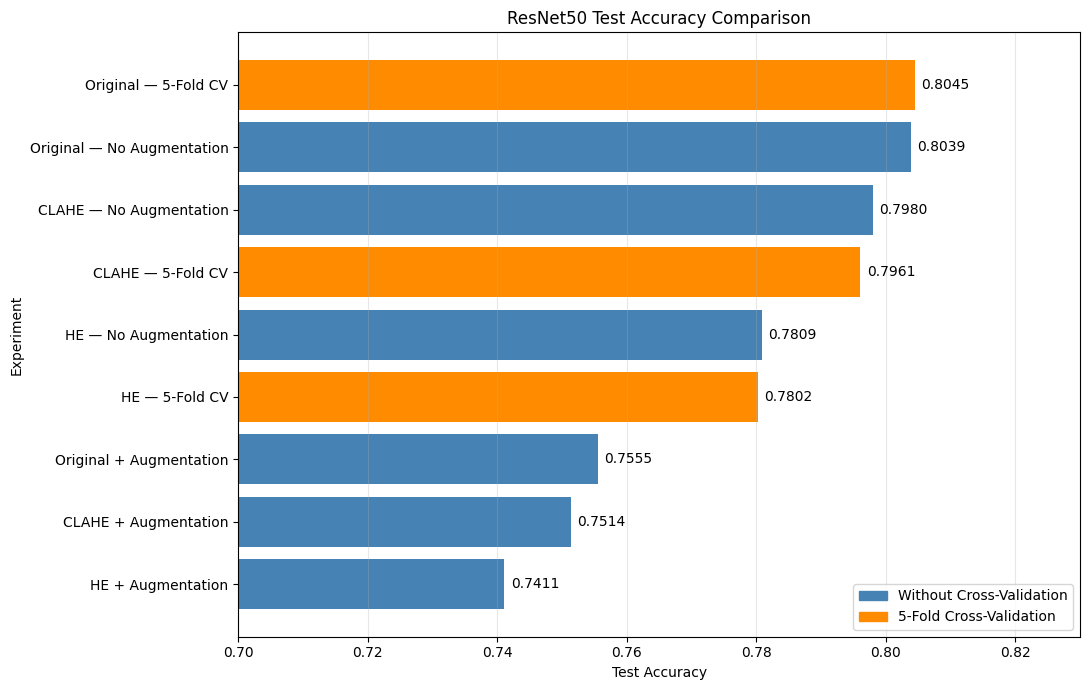

In [4]:
accuracy_plot_df = results_df.sort_values(
    "Accuracy",
    ascending=True
)

colors = accuracy_plot_df[
    "Cross-Validation"
].map({
    "No": "steelblue",
    "5-Fold": "darkorange"
})

plt.figure(figsize=(11, 7))

bars = plt.barh(
    accuracy_plot_df["Experiment"],
    accuracy_plot_df["Accuracy"],
    color=colors
)

plt.xlim(0.70, 0.83)
plt.title("ResNet50 Test Accuracy Comparison")
plt.xlabel("Test Accuracy")
plt.ylabel("Experiment")
plt.grid(axis="x", alpha=0.3)

for bar, value in zip(
    bars,
    accuracy_plot_df["Accuracy"]
):
    plt.text(
        value + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center"
    )

from matplotlib.patches import Patch

plt.legend(
    handles=[
        Patch(
            color="steelblue",
            label="Without Cross-Validation"
        ),
        Patch(
            color="darkorange",
            label="5-Fold Cross-Validation"
        )
    ],
    loc="lower right"
)

plt.tight_layout()
plt.show()

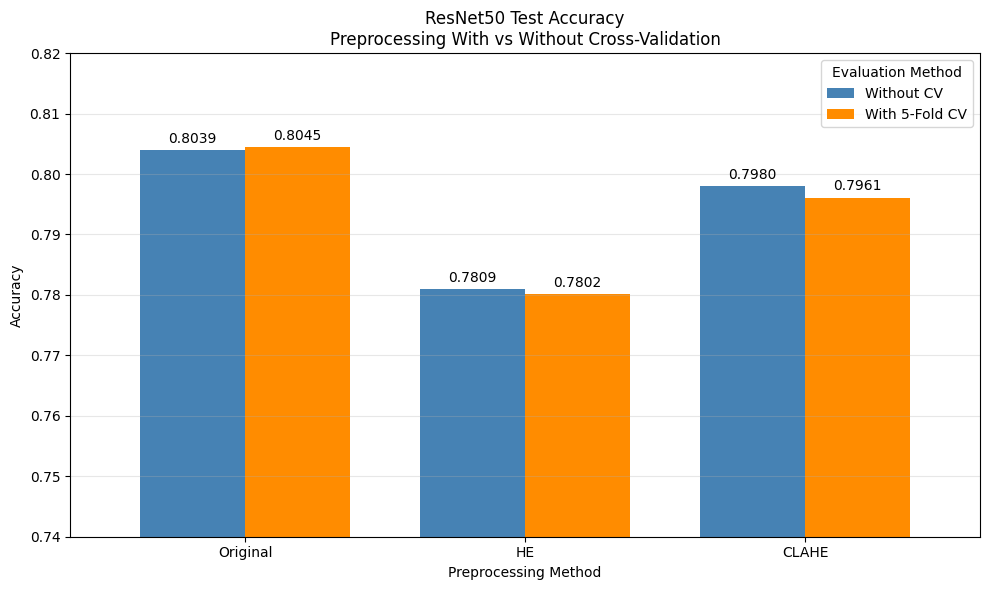

In [5]:
noaug_df = results_df[
    results_df["Augmentation"] == "No"
].copy()

accuracy_pivot = noaug_df.pivot(
    index="Preprocessing",
    columns="Cross-Validation",
    values="Accuracy"
)

accuracy_pivot = accuracy_pivot.reindex(
    ["Original", "HE", "CLAHE"]
)

accuracy_pivot = accuracy_pivot[
    ["No", "5-Fold"]
]

accuracy_pivot.columns = [
    "Without CV",
    "With 5-Fold CV"
]

ax = accuracy_pivot.plot(
    kind="bar",
    figsize=(10, 6),
    color=["steelblue", "darkorange"],
    width=0.75
)

plt.title(
    "ResNet50 Test Accuracy\n"
    "Preprocessing With vs Without Cross-Validation"
)
plt.xlabel("Preprocessing Method")
plt.ylabel("Accuracy")
plt.ylim(0.74, 0.82)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

plt.legend(title="Evaluation Method")
plt.tight_layout()
plt.show()

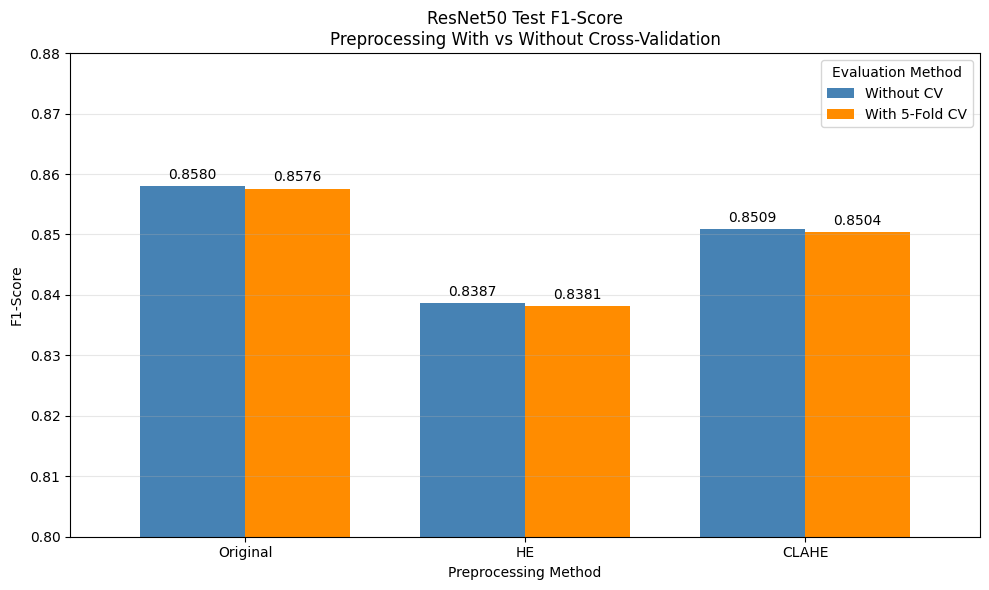

In [6]:
f1_pivot = noaug_df.pivot(
    index="Preprocessing",
    columns="Cross-Validation",
    values="F1-score"
)

f1_pivot = f1_pivot.reindex(
    ["Original", "HE", "CLAHE"]
)

f1_pivot = f1_pivot[
    ["No", "5-Fold"]
]

f1_pivot.columns = [
    "Without CV",
    "With 5-Fold CV"
]

ax = f1_pivot.plot(
    kind="bar",
    figsize=(10, 6),
    color=["steelblue", "darkorange"],
    width=0.75
)

plt.title(
    "ResNet50 Test F1-Score\n"
    "Preprocessing With vs Without Cross-Validation"
)
plt.xlabel("Preprocessing Method")
plt.ylabel("F1-Score")
plt.ylim(0.80, 0.88)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

plt.legend(title="Evaluation Method")
plt.tight_layout()
plt.show()

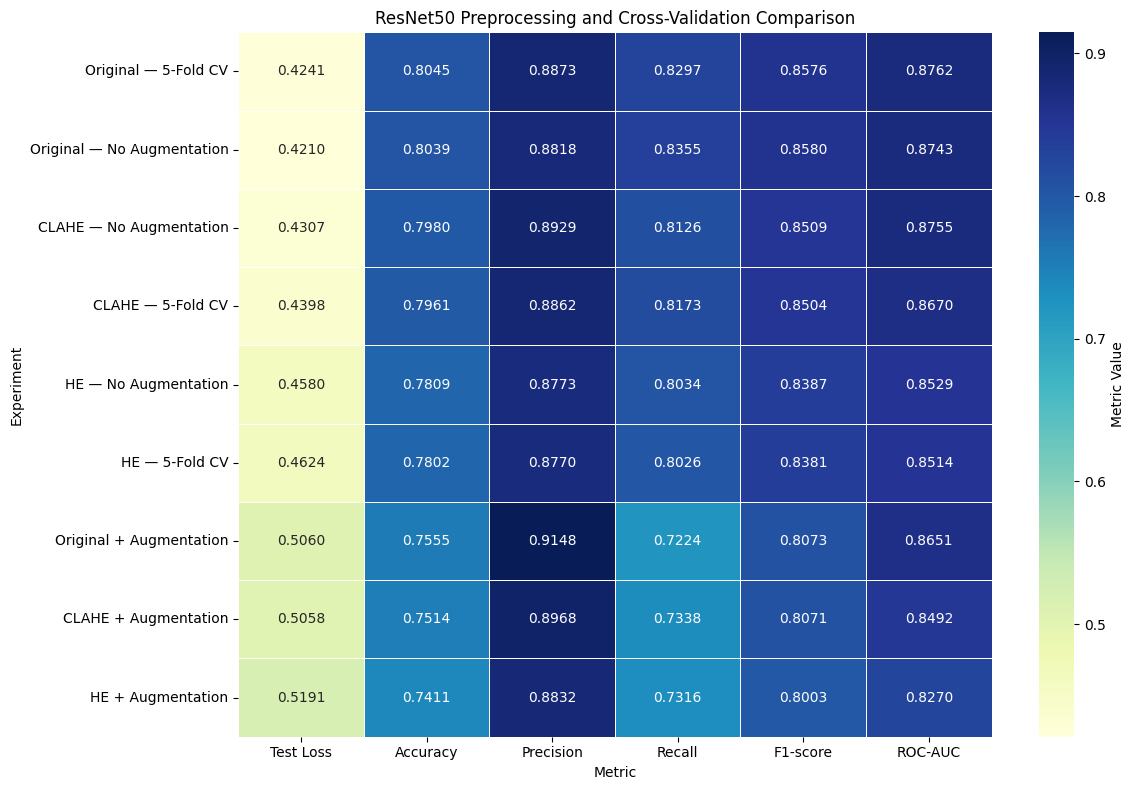

In [7]:
heatmap_df = ranking_df.set_index(
    "Experiment"
)[
    [
        "Test Loss",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ]
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Metric Value"}
)

plt.title(
    "ResNet50 Preprocessing and Cross-Validation Comparison"
)
plt.xlabel("Metric")
plt.ylabel("Experiment")
plt.tight_layout()
plt.show()

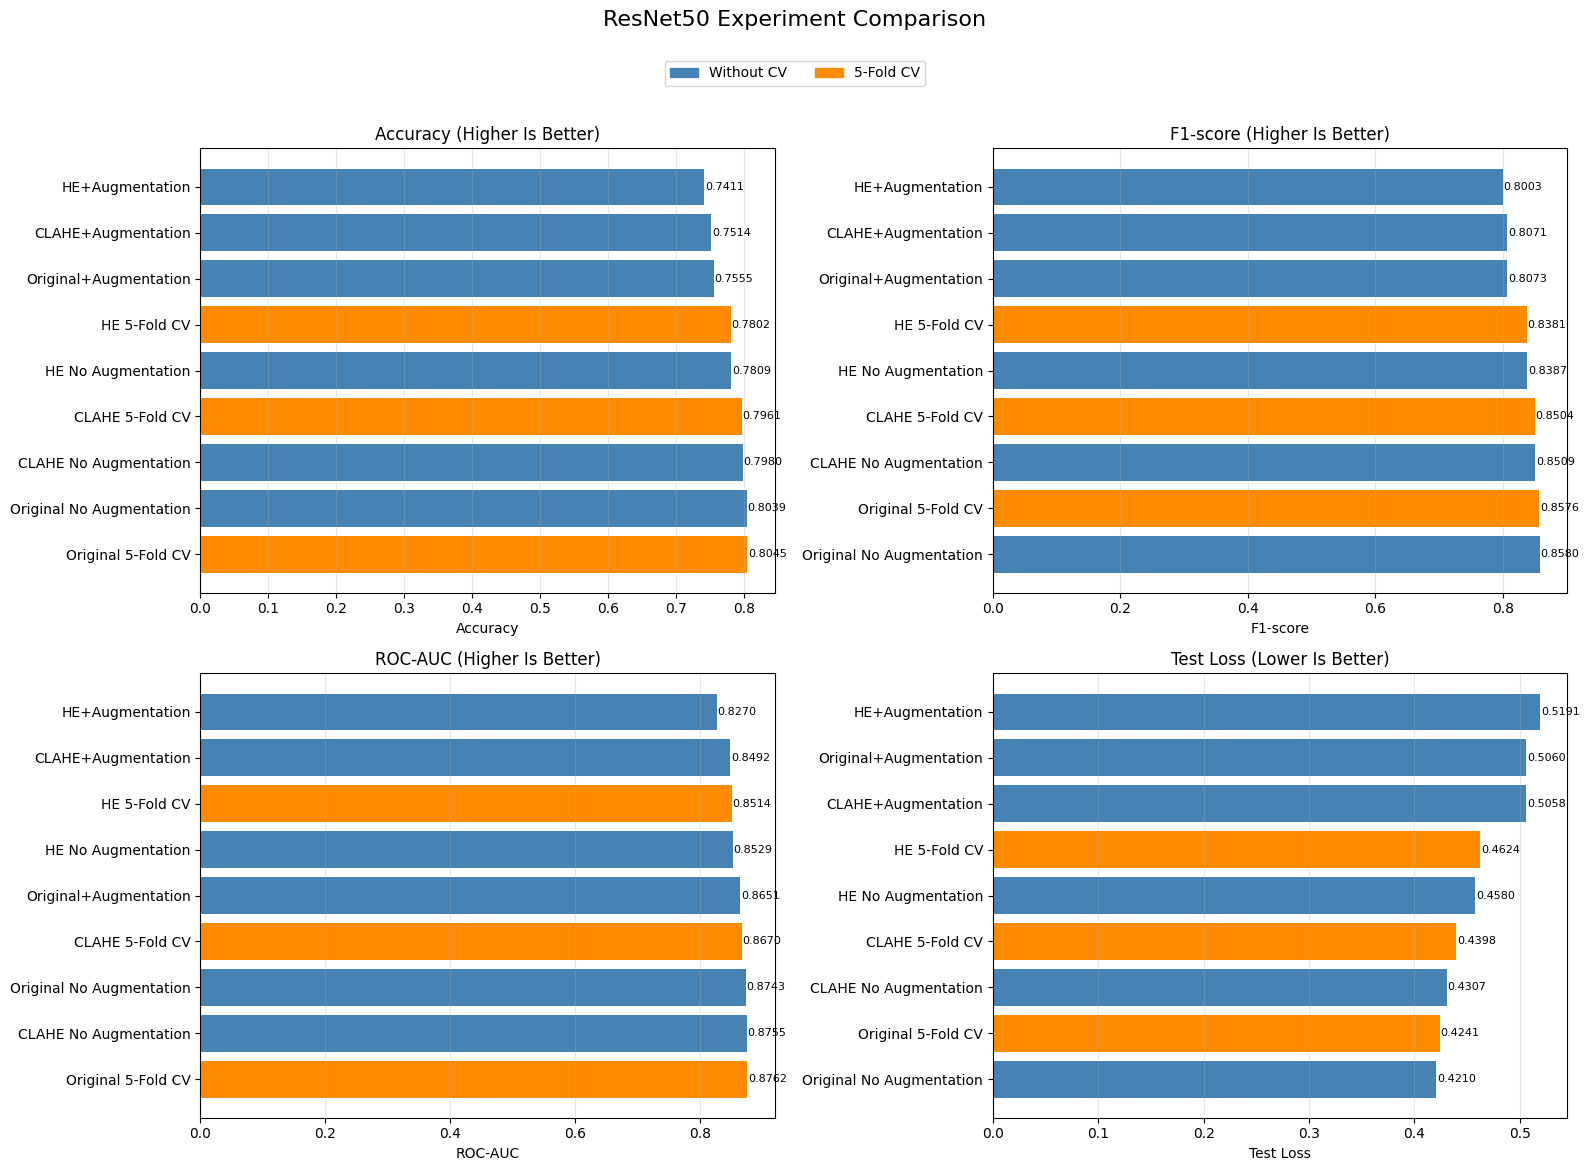

In [8]:
plot_metrics = [
    "Accuracy",
    "F1-score",
    "ROC-AUC",
    "Test Loss"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11)
)

axes = axes.flatten()

plot_df = ranking_df.copy()
plot_df["Short Experiment"] = plot_df[
    "Experiment"
].str.replace(
    " Without Augmentation",
    " NoAug",
    regex=False
).str.replace(
    " With Augmentation",
    " Aug",
    regex=False
).str.replace(
    " — ",
    " ",
    regex=False
).str.replace(
    " + ",
    "+",
    regex=False
)

for ax, metric in zip(axes, plot_metrics):
    metric_df = plot_df.sort_values(
        metric,
        ascending=(metric == "Test Loss")
    )

    colors = metric_df[
        "Cross-Validation"
    ].map({
        "No": "steelblue",
        "5-Fold": "darkorange"
    })

    bars = ax.barh(
        metric_df["Short Experiment"],
        metric_df[metric],
        color=colors
    )

    ax.set_title(
        f"{metric} "
        f"({'Lower Is Better' if metric == 'Test Loss' else 'Higher Is Better'})"
    )
    ax.set_xlabel(metric)
    ax.grid(axis="x", alpha=0.3)

    for bar, value in zip(
        bars,
        metric_df[metric]
    ):
        ax.text(
            value + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va="center",
            fontsize=8
        )

from matplotlib.patches import Patch

fig.legend(
    handles=[
        Patch(
            color="steelblue",
            label="Without CV"
        ),
        Patch(
            color="darkorange",
            label="5-Fold CV"
        )
    ],
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.02)
)

plt.suptitle(
    "ResNet50 Experiment Comparison",
    fontsize=16,
    y=1.06
)

plt.tight_layout()
plt.show()

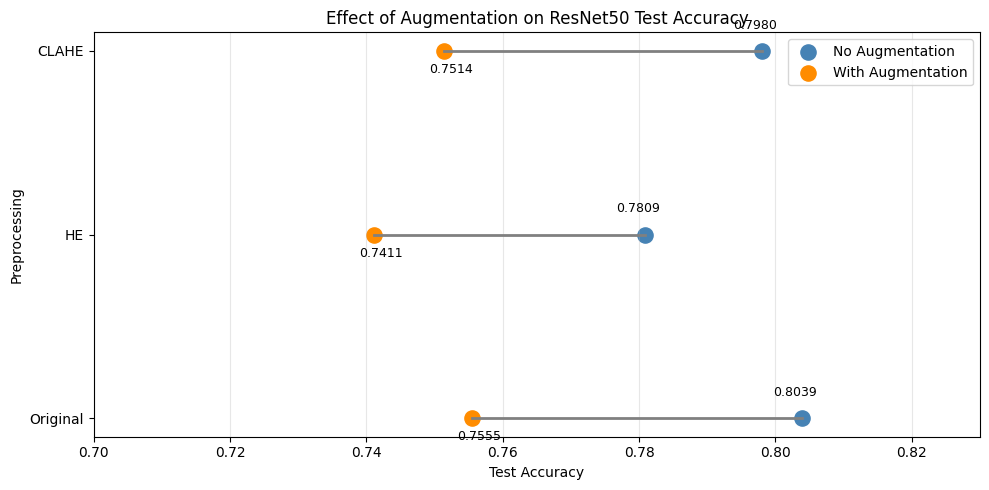

In [9]:
no_cv_df = results_df[
    results_df["Cross-Validation"] == "No"
].copy()

augmentation_pivot = no_cv_df.pivot(
    index="Preprocessing",
    columns="Augmentation",
    values="Accuracy"
).reindex(
    ["Original", "HE", "CLAHE"]
)

plt.figure(figsize=(10, 5))

y_positions = np.arange(
    len(augmentation_pivot)
)

for position, preprocessing in enumerate(
    augmentation_pivot.index
):
    no_aug_accuracy = augmentation_pivot.loc[
        preprocessing, "No"
    ]

    aug_accuracy = augmentation_pivot.loc[
        preprocessing, "Yes"
    ]

    plt.plot(
        [no_aug_accuracy, aug_accuracy],
        [position, position],
        color="gray",
        linewidth=2
    )

    plt.scatter(
        no_aug_accuracy,
        position,
        color="steelblue",
        s=120,
        label="No Augmentation"
        if position == 0 else None
    )

    plt.scatter(
        aug_accuracy,
        position,
        color="darkorange",
        s=120,
        label="With Augmentation"
        if position == 0 else None
    )

    plt.text(
        no_aug_accuracy - 0.001,
        position + 0.12,
        f"{no_aug_accuracy:.4f}",
        ha="center",
        fontsize=9
    )

    plt.text(
        aug_accuracy + 0.001,
        position - 0.12,
        f"{aug_accuracy:.4f}",
        ha="center",
        fontsize=9
    )

plt.yticks(
    y_positions,
    augmentation_pivot.index
)

plt.xlim(0.70, 0.83)
plt.xlabel("Test Accuracy")
plt.ylabel("Preprocessing")
plt.title(
    "Effect of Augmentation on ResNet50 Test Accuracy"
)
plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()